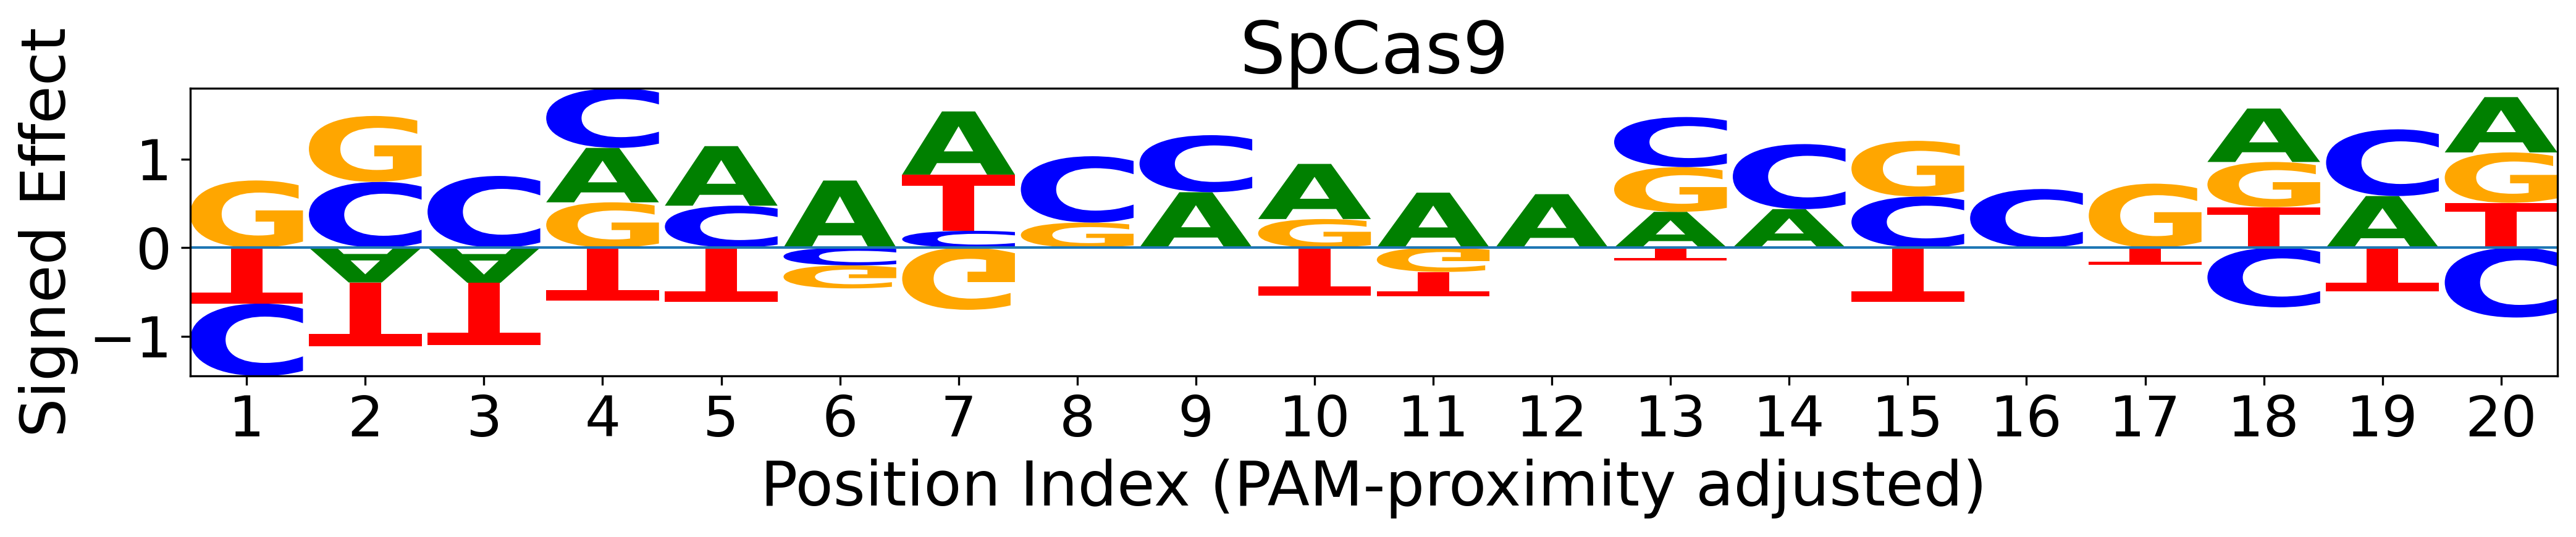

Saved to: indiv_SpCas9_computed_spearman_by_base_position.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

def load_logo_matrix(csv_path, value_col="Median Spearman Correlation"):
    df = pd.read_csv(csv_path)
    df[['Pos', 'Base']] = df['Feature'].str.extract(r'Pos(\d+)_(\w)')
    df['Pos'] = df['Pos'].astype(int)
    mat = df.pivot(index="Base", columns="Pos", values=value_col)
    return mat

# ---- Load positive and negative matrices ----
pos_mat = load_logo_matrix("indiv_features_with_positive_IQR_Cas9_cnn1.csv")
neg_mat = load_logo_matrix("indiv_features_with_negative_IQR_Cas9_cnn1.csv")

# ---- Ensure consistent bases and positions ----
base_order = ['A', 'C', 'G', 'T']   # change to ['A','C','G','U'] if RNA
pos_mat = pos_mat.reindex(base_order)
neg_mat = neg_mat.reindex(base_order)

all_pos = sorted(set(pos_mat.columns).union(set(neg_mat.columns)))
pos_mat = pos_mat.reindex(columns=all_pos)
neg_mat = neg_mat.reindex(columns=all_pos)

# ---- Build signed matrix: positive above 0, negative below 0 ----
# pos values are already >= 0
# neg values are <= 0; convert to negative magnitudes for plotting
pos_vals = pos_mat.fillna(0.0)
neg_vals = neg_mat.fillna(0.0)

signed_mat = pos_vals + (-np.abs(neg_vals))  # keeps pos; makes neg go downward

# ---- PAM-proximity adjustment: reverse AND renumber ----
# Ensure numeric order first (important if columns are not strictly sorted)
signed_mat = signed_mat.reindex(sorted(signed_mat.columns), axis=1)

# Reverse the *data* order (e.g., 20→1 becomes left→right)
signed_mat = signed_mat.iloc[:, ::-1]

# Renumber columns so new position 1 is PAM-proximal, 2 next, ...
n_pos = signed_mat.shape[1]
signed_mat.columns = range(1, n_pos + 1)

# Convert to logomaker format: rows=positions, cols=bases
logo_df = signed_mat.T.copy()  # index=Pos, columns=bases

# ---- Plot signed logo ----
fig, ax = plt.subplots(figsize=(14, 3), dpi=300)

logomaker.Logo(logo_df, ax=ax)

# Zero baseline
ax.axhline(0, linewidth=1)

# X ticks start at 1 (display only)
n_pos = logo_df.shape[0]

ax.set_xticks(range(1, n_pos + 1))
ax.set_xticklabels(range(1, n_pos + 1), fontsize=22)

from matplotlib.ticker import MaxNLocator

ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=24)
ax.set_ylabel("Signed Effect", fontsize=24)
ax.set_title("SpCas9", fontsize=28)

plt.tight_layout()
plt.show()

import pandas as pd
import numpy as np

out_df = (
    signed_mat
    .reset_index()  # Base becomes a column
    .melt(id_vars="Base", var_name="Position", value_name="Computed_Spearman")
)

# Ensure types
out_df["Position"] = out_df["Position"].astype(int)
out_df["Computed_Spearman"] = out_df["Computed_Spearman"].astype(float)

# Sign column (same style: positive / negative / zero)
out_df["Sign"] = np.where(
    out_df["Computed_Spearman"] > 0, "positive",
    np.where(out_df["Computed_Spearman"] < 0, "negative", "zero")
)

# Sort like a clean table: by Position then Base
base_order = ['A', 'C', 'G', 'T']  # change if RNA
out_df["Base"] = pd.Categorical(out_df["Base"], categories=base_order, ordered=True)
out_df = out_df.sort_values(["Position", "Base"]).reset_index(drop=True)

# Save
out_df.to_csv("indiv_SpCas9_computed_spearman_by_base_position.csv", index=False)

# If you also want it as a Python list of dicts:
as_list = out_df.to_dict(orient="records")

print("Saved to: indiv_SpCas9_computed_spearman_by_base_position.csv")



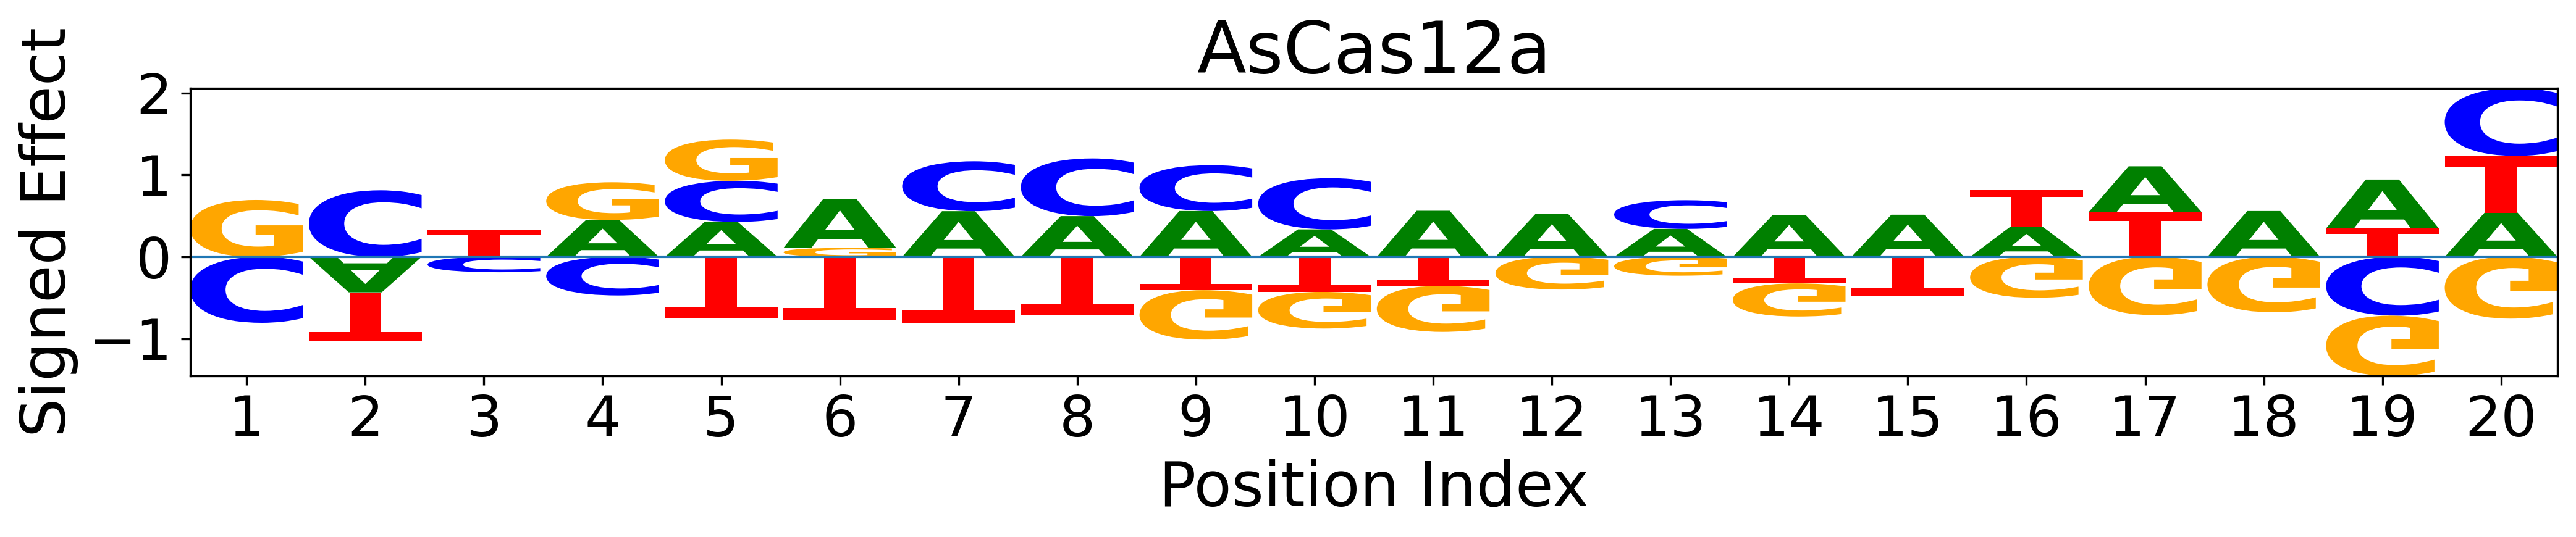

Saved to: indiv_AsCas12a_computed_spearman_by_base_position.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

def load_logo_matrix(csv_path, value_col="Median Spearman Correlation"):
    df = pd.read_csv(csv_path)
    df[['Pos', 'Base']] = df['Feature'].str.extract(r'Pos(\d+)_(\w)')
    df['Pos'] = df['Pos'].astype(int)
    mat = df.pivot(index="Base", columns="Pos", values=value_col)
    return mat

# ---- Load positive and negative matrices ----
pos_mat = load_logo_matrix("indiv_features_with_positive_IQR_HT11_unique_cnn1.csv")
neg_mat = load_logo_matrix("indiv_features_with_negative_IQR_HT11_unique_cnn1.csv")

# ---- Ensure consistent bases and positions ----
base_order = ['A', 'C', 'G', 'T']  # change to ['A','C','G','U'] if RNA
pos_mat = pos_mat.reindex(base_order)
neg_mat = neg_mat.reindex(base_order)

all_pos = sorted(set(pos_mat.columns).union(set(neg_mat.columns)))
pos_mat = pos_mat.reindex(columns=all_pos)
neg_mat = neg_mat.reindex(columns=all_pos)

# ---- Build signed matrix: positive above 0, negative below 0 ----
# pos values are already >= 0
# neg values are <= 0; convert to negative magnitudes for plotting
pos_vals = pos_mat.fillna(0.0)
neg_vals = neg_mat.fillna(0.0)

signed_mat = pos_vals + (-np.abs(neg_vals))  # keeps pos; makes neg go downward

# ---- PAM-proximity adjustment: reverse AND renumber ----
# Ensure numeric order first (important if columns are not strictly sorted)
signed_mat = signed_mat.reindex(sorted(signed_mat.columns), axis=1)

# Renumber columns so new position 1 is PAM-proximal, 2 next, ...
n_pos = signed_mat.shape[1]
signed_mat.columns = range(1, n_pos + 1)

# Convert to logomaker format: rows=positions, cols=bases
logo_df = signed_mat.T.copy()  # index=Pos, columns=bases

# ---- Plot signed logo ----
fig, ax = plt.subplots(figsize=(14, 3), dpi=300)

logomaker.Logo(logo_df, ax=ax)

# Zero baseline
ax.axhline(0, linewidth=1)

# X ticks start at 1 (display only)
n_pos = logo_df.shape[0]

ax.set_xticks(range(1, n_pos + 1))
ax.set_xticklabels(range(1, n_pos + 1), fontsize=22)

from matplotlib.ticker import MaxNLocator

ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Position Index", fontsize=24)
ax.set_ylabel("Signed Effect", fontsize=24)
ax.set_title("AsCas12a", fontsize=28)

plt.tight_layout()
plt.show()


import pandas as pd
import numpy as np

out_df = (
    signed_mat
    .reset_index()  # Base becomes a column
    .melt(id_vars="Base", var_name="Position", value_name="Computed_Spearman")
)

# Ensure types
out_df["Position"] = out_df["Position"].astype(int)
out_df["Computed_Spearman"] = out_df["Computed_Spearman"].astype(float)


# Sign column (same style: positive / negative / zero)
out_df["Sign"] = np.where(
    out_df["Computed_Spearman"] > 0, "positive",
    np.where(out_df["Computed_Spearman"] < 0, "negative", "zero")
)

# Sort like a clean table: by Position then Base
base_order = ['A', 'C', 'G', 'T']  # change if RNA
out_df["Base"] = pd.Categorical(out_df["Base"], categories=base_order, ordered=True)
out_df = out_df.sort_values(["Position", "Base"]).reset_index(drop=True)

# Save
out_df.to_csv("indiv_AsCas12a_computed_spearman_by_base_position.csv", index=False)

# If you also want it as a Python list of dicts:
as_list = out_df.to_dict(orient="records")

print("Saved to: indiv_AsCas12a_computed_spearman_by_base_position.csv")


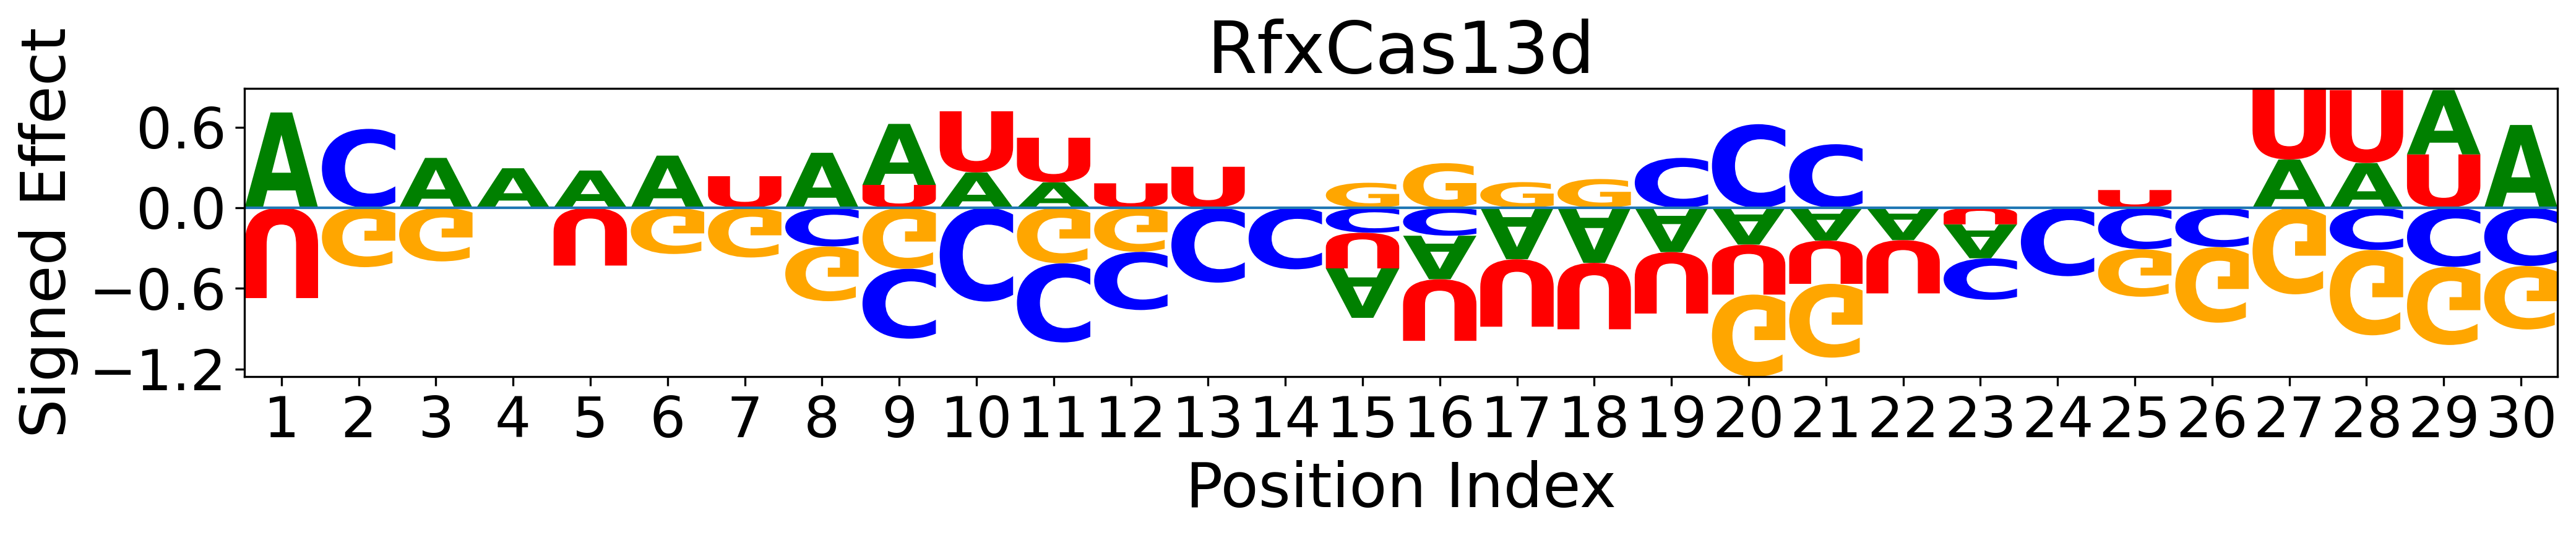

Saved to: indiv_RfxCas13d_validation_computed_spearman_by_base_position.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logomaker

def load_logo_matrix(csv_path, value_col="Median Spearman Correlation"):
    df = pd.read_csv(csv_path)
    df[['Pos', 'Base']] = df['Feature'].str.extract(r'Pos(\d+)_(\w)')
    df['Pos'] = df['Pos'].astype(int)
    mat = df.pivot(index="Base", columns="Pos", values=value_col)
    return mat

# ---- Load positive and negative matrices ----
pos_mat = load_logo_matrix("indiv_features_with_positive_IQR_RfxCas13a_validation_cnn1.csv")
neg_mat = load_logo_matrix("indiv_features_with_negative_IQR_RfxCas13a_validation_cnn1.csv")

# ---- Ensure consistent bases and positions ----
base_order = ['A', 'C', 'G', 'U']  # change to ['A','C','G','U'] if RNA
pos_mat = pos_mat.reindex(base_order)
neg_mat = neg_mat.reindex(base_order)

all_pos = list(range(37, 67))   # guarantees 30 columns
pos_mat = pos_mat.reindex(columns=all_pos)
neg_mat = neg_mat.reindex(columns=all_pos)

# ---- Build signed matrix: positive above 0, negative below 0 ----
# pos values are already >= 0
# neg values are <= 0; convert to negative magnitudes for plotting
pos_vals = pos_mat.fillna(0.0)
neg_vals = neg_mat.fillna(0.0)

signed_mat = pos_vals + (-np.abs(neg_vals))  # keeps pos; makes neg go downward

# ---- PAM-proximity adjustment: reverse AND renumber ----
# Ensure numeric order first (important if columns are not strictly sorted)
signed_mat = signed_mat.reindex(sorted(signed_mat.columns), axis=1)

# Renumber columns so new position 1 is PAM-proximal, 2 next, ...
n_pos = signed_mat.shape[1]
signed_mat.columns = range(1, n_pos + 1)

# Convert to logomaker format: rows=positions, cols=bases
logo_df = signed_mat.T.copy()  # index=Pos, columns=bases

# ---- Plot signed logo ----
fig, ax = plt.subplots(figsize=(14, 3), dpi=300)

logomaker.Logo(logo_df, ax=ax)

# Zero baseline
ax.axhline(0, linewidth=1)

# X ticks start at 1 (display only)
n_pos = logo_df.shape[0]

ax.set_xticks(range(1, n_pos + 1))
ax.set_xticklabels(range(1, n_pos + 1), fontsize=22)

from matplotlib.ticker import MaxNLocator

ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.tick_params(axis='y', labelsize=22)

ax.set_xlabel("Position Index", fontsize=24)
ax.set_ylabel("Signed Effect", fontsize=24)
ax.set_title("RfxCas13d", fontsize=28)

plt.tight_layout()
plt.show()


import pandas as pd
import numpy as np

out_df = (
    signed_mat
    .reset_index()  # Base becomes a column
    .melt(id_vars="Base", var_name="Position", value_name="Computed_Spearman")
)

# Ensure types
out_df["Position"] = out_df["Position"].astype(int)
out_df["Computed_Spearman"] = out_df["Computed_Spearman"].astype(float)


# Sign column (same style: positive / negative / zero)
out_df["Sign"] = np.where(
    out_df["Computed_Spearman"] > 0, "positive",
    np.where(out_df["Computed_Spearman"] < 0, "negative", "zero")
)

# Sort like a clean table: by Position then Base
base_order = ['A', 'C', 'G', 'U']  # change if RNA
out_df["Base"] = pd.Categorical(out_df["Base"], categories=base_order, ordered=True)
out_df = out_df.sort_values(["Position", "Base"]).reset_index(drop=True)

# Save
out_df.to_csv("indiv_RfxCas13d_validation_computed_spearman_by_base_position.csv", index=False)

# If you also want it as a Python list of dicts:
as_list = out_df.to_dict(orient="records")

print("Saved to: indiv_RfxCas13d_validation_computed_spearman_by_base_position.csv")
